# Import các thư viện cần thiểt

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import os
from torchsummary import summary
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision.transforms import transforms, functional
from sklearn.model_selection import train_test_split
import os
import sys
from torchvision.datasets import FashionMNIST
import torch.nn.init as init

Thêm nối thư mục hiện tại với thư mục chứa file MLP.py

In [2]:
sys.path.append(os.path.abspath('../BaseMLP'))

In [3]:
from MLP import *

In [4]:
# Tạo thư mục data/ để chứa DL
os.makedirs(name='../data/', exist_ok=True)

In [5]:
TrainData = FashionMNIST(
    root='../data/',
    download=True,
)

100%|█████████████████████████████████████████████████████████████████████████████| 26.4M/26.4M [00:15<00:00, 1.76MB/s]
100%|██████████████████████████████████████████████████████████████████████████████| 29.5k/29.5k [00:00<00:00, 137kB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 4.42M/4.42M [00:03<00:00, 1.28MB/s]
100%|█████████████████████████████████████████████████████████████████████████████| 5.15k/5.15k [00:00<00:00, 18.6MB/s]


In [6]:
TrainData[0]

(<PIL.Image.Image image mode=L size=28x28>, 9)

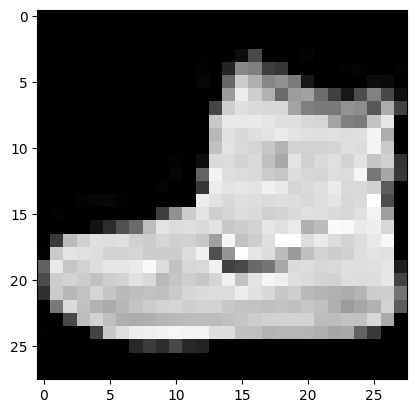

In [7]:
# Hiển thị ảnh đầu tiên của bộ DL
plt.imshow(TrainData[0][0], cmap='gray')

In [9]:
# Chuyển Đổi ảnh về dạng Tensor và chuẩn hóa DL ảnh thông qua tham số transforms
TrainData = FashionMNIST(
    root='../data/', # Nơi lưu trữ DL của ảnh được tải về
    download=True, # Tham số thiết lập có tải xuống nếu trong thư mục chưa có DL
    transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(0.5,), std = (0.5,))]),# Các phép biến đổi ảnh
    train=True # Lấy ra tập trainset đã được chia
)

In [12]:
img, label = TrainData[0]

In [13]:
img.shape

torch.Size([1, 28, 28])

In [15]:
img

tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1

# Xây dựng mô hình CNN base cho tập DL Fashion MNIST

In [16]:
BaseMLP??

Init signature: BaseMLP()
Source:        
class BaseMLP(ABC):
    r"""
    abstract class - Lớp trừu tượng - Tạo bộ khung, mẫu cho class BASEMLP

    All subclass should overwrite metthod 'predict' to get prediction of model throught
    logits = self.Forward().
    Subclass also should overwrite metthod 'get_accuracy' to get accuracy from 2 parameter logits and y
    Subclass also should overwrite metthod 'compute_loss' to get loss_value from self.criterion
    """


    def __init__(self):
        self.Layers = []
        self.model = None
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.criterion = None
    
    @abstractmethod
    def predict(self,X):
        pass
    @abstractmethod
    def get_accuracy(self,logits,y):
        pass
    @abstractmethod
    def compute_loss(self,logits, y):
        pass
    
    def Add_layer(self,layers):
        if not isinstance(layers, list):
            raise TypeError("layers must be a list")
        self.Layer

In [17]:
class BaseCNN(BaseMLP):
    def __init__(self):
        # Kế thừa toàn bộ method and properties
        super().__init__()
    def predict(self,X):
        with torch.no_grad():
            self.model.eval()
            X = X.to(self.device)
            logits = self.forward(X)
            return torch.argmax(logits,dim = 1)
    def get_accuracy(self,logits,y):
        try:
            return torch.mean((torch.argmax(logits,dim = 1) == torch.argmax(y, dim =1)).float())
        except:
            return torch.mean((torch.argmax(logits,dim = 1) == y).float())
    def compute_loss(self, logits, y):
        return self.criterion(logits,y)

In [18]:
# Xây dựng mô hình CNN cho bộ DL MNIST
CNN = BaseCNN()

In [19]:
# Build Layers for model
# Block 1:
CNN.Add_layer([
    nn.Conv2d(in_channels=1, out_channels=64, kernel_size=3, padding='same', stride=1),
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2)
])

# Block 2:
CNN.Add_layer([
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding='same', stride=1),
    nn.GELU(),
    nn.MaxPool2d(kernel_size=2, stride=2)
])

# Block 3:
CNN.Add_layer([
    nn.Conv2d(in_channels=128, out_channels=128, kernel_size=3, padding='same', stride=1),
    nn.GELU(),
    nn.Flatten()
])

# Block4:
CNN.Add_layer([
    nn.Linear(in_features=7*7*128, out_features=128, bias=True),
    nn.GELU(),
    nn.Linear(in_features=128, out_features=10, bias = True)
])

In [20]:
summary(CNN.model, input_size=(1,28,28), batch_size=512, device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [512, 64, 28, 28]             640
              GELU-2          [512, 64, 28, 28]               0
         MaxPool2d-3          [512, 64, 14, 14]               0
            Conv2d-4         [512, 128, 14, 14]          73,856
              GELU-5         [512, 128, 14, 14]               0
         MaxPool2d-6           [512, 128, 7, 7]               0
            Conv2d-7           [512, 128, 7, 7]         147,584
              GELU-8           [512, 128, 7, 7]               0
           Flatten-9                [512, 6272]               0
           Linear-10                 [512, 128]         802,944
             GELU-11                 [512, 128]               0
           Linear-12                  [512, 10]           1,290
Total params: 1,026,314
Trainable params: 1,026,314
Non-trainable params: 0
---------------------------

In [24]:
# Khởi tạo kamin_he_init
for layer in CNN.model:
    if isinstance(layer,nn.Conv2d) or isinstance(layer, nn.Linear):
        init.kaiming_uniform_(layer.weight)
        init.zeros_(layer.bias)

In [33]:
# Huấn Luyện Mô hình
CNN.fit(dataset=TrainData, batch_size=512, n_epochs=30, lr = 1e-03, verbose=2, is_shuffle=True, validation_split=0.2, criterion='CE',optimizer='Adam')

  0%|                                                                                           | 0/30 [00:00<?, ?it/s]

Epoch [   1/30]


  3%|██▊                                                                                | 1/30 [00:37<18:02, 37.34s/it]

Loss = 0.6344 - Accuracy = 0.7932 - Loss_Validation = 0.3607 - Accracy_Validation = 0.8702
Epoch [   2/30]


  7%|█████▌                                                                             | 2/30 [01:02<14:12, 30.44s/it]

...

Loss = 0.0212 - Accuracy = 0.9926 - Loss_Validation = 0.3968 - Accracy_Validation = 0.9255
Epoch [  29/30]


 97%|███████████████████████████████████████████████████████████████████████████████▎  | 29/30 [12:24<00:25, 25.40s/it]

Loss = 0.0126 - Accuracy = 0.9956 - Loss_Validation = 0.4236 - Accracy_Validation = 0.9182
Epoch [  30/30]


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [12:49<00:00, 25.66s/it]

Loss = 0.0136 - Accuracy = 0.9954 - Loss_Validation = 0.4276 - Accracy_Validation = 0.9213


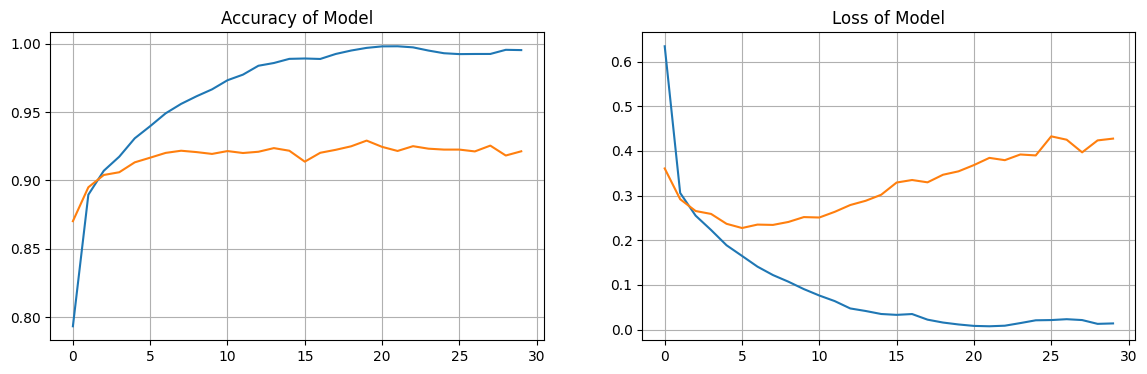

In [45]:
fig, axs = plt.subplots(1,2, figsize = (14,4))
axs[0].plot(CNN.Accuracies)
axs[0].plot(CNN.Val_Accuracies)
axs[0].set_title("Accuracy of Model")
axs[0].grid()

axs[1].plot(CNN.Losses)
axs[1].plot(CNN.Val_Losses)
axs[1].set_title("Loss of Model")
axs[1].grid()

In [49]:
TestData = FashionMNIST(
    root='data/', # Nơi lưu trữ DL của ảnh được tải về
    download=True, # Tham số thiết lập có tải xuống nếu trong thư mục chưa có DL
    transform=transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=(0.5,), std = (0.5,))]),# Các phép biến đổi ảnh
    train=False # Lấy ra tập trainset đã được chia
)

In [54]:
X_test, y_test = zip(*TestData)

In [55]:
X_test = torch.stack(X_test)
X_test.shape

torch.Size([10000, 1, 28, 28])

In [58]:
y_test = torch.tensor(y_test).to(CNN.device)

In [56]:
X_test = X_test.to(CNN.device)

In [57]:
logits = CNN.forward(X_test)

In [59]:
print(f"Độ chính xác của mô hình {CNN.get_accuracy(logits,y_test)}")

Độ chính xác của mô hình 0.9131999611854553
